In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"c:\Users\sarth\Downloads\Airline_Delay_Cause.csv")


In [3]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
year,2025,2025,2025,2025,2025,2025,2025,2025,2025,2025
month,1,1,1,1,1,1,1,1,1,1
carrier,G4,G4,G4,G4,G4,G4,G4,G4,G4,G4
carrier_name,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air,Allegiant Air
airport,ELM,ELP,EUG,EVV,EWR,EYW,FAR,FAT,FCA,FLL
airport_name,"Elmira/Corning, NY: Elmira/Corning Regional","El Paso, TX: El Paso International","Eugene, OR: Mahlon Sweet Field","Evansville, IN: Evansville Regional","Newark, NJ: Newark Liberty International","Key West, FL: Key West International","Fargo, ND: Hector International","Fresno, CA: Fresno Yosemite International","Kalispell, MT: Glacier Park International","Fort Lauderdale, FL: Fort Lauderdale-Hollywood..."
arr_flights,30.0,2.0,28.0,18.0,31.0,73.0,75.0,39.0,28.0,326.0
arr_del15,0.0,0.0,8.0,1.0,5.0,8.0,8.0,12.0,3.0,104.0
carrier_ct,0.0,0.0,3.74,0.0,2.17,4.69,4.34,1.55,1.0,22.59
weather_ct,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.47,1.0,10.79


In [4]:
df.shape

(398233, 21)

In [5]:
df.columns

Index(['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name',
       'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct',
       'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted',
       'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [6]:
df['year'].nunique()

23

In [7]:
df['airport_name'].nunique()

449

In [8]:
df['carrier_name'].nunique()

51

HERE I WANT TO KNOW WHETHER THE DELAY INCREASES OR DECREASES AS THE YEAR GOES ON

In [10]:
df["delay_rate"] = df["arr_del15"]/df["arr_flights"] 

In [11]:
yearly_rate = df.groupby("year")["delay_rate"].mean()

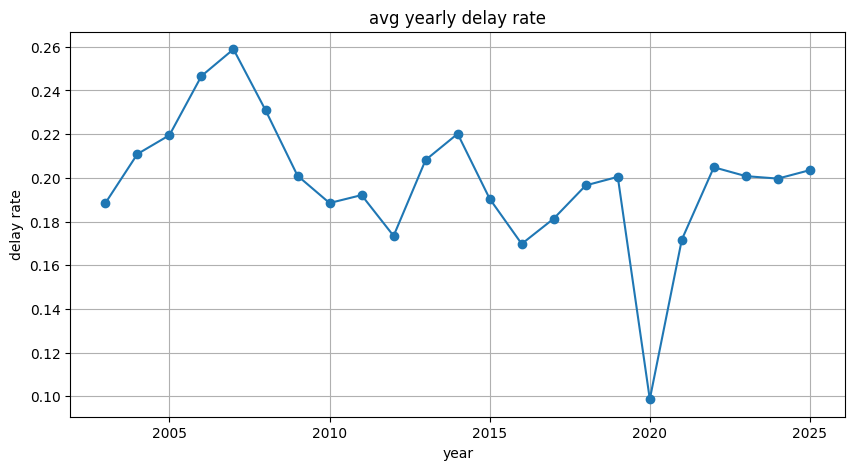

In [12]:
plt.figure(figsize=(10,5))
plt.plot(yearly_rate.index, yearly_rate.values, marker="o")
plt.title("avg yearly delay rate")
plt.xlabel("year")
plt.ylabel("delay rate")
plt.grid(True)
plt.show()

NOW I WANT TO SEE THE MONTHLY TREND IN DELAY

In [13]:
monthly_rate = df.groupby("month")["delay_rate"].mean()


In [ ]:
month_name = {
    1: "jan", 2: "feb",
    3: "mar", 4: "apr", 5:"may",
    6: "jun", 7:"july", 8: "aug",
    9: "sep", 10: "oct", 11: "nov",
    12: "dec"
}

In [15]:
monthly_rate.index = [month_name[m] for m in monthly_rate.index]

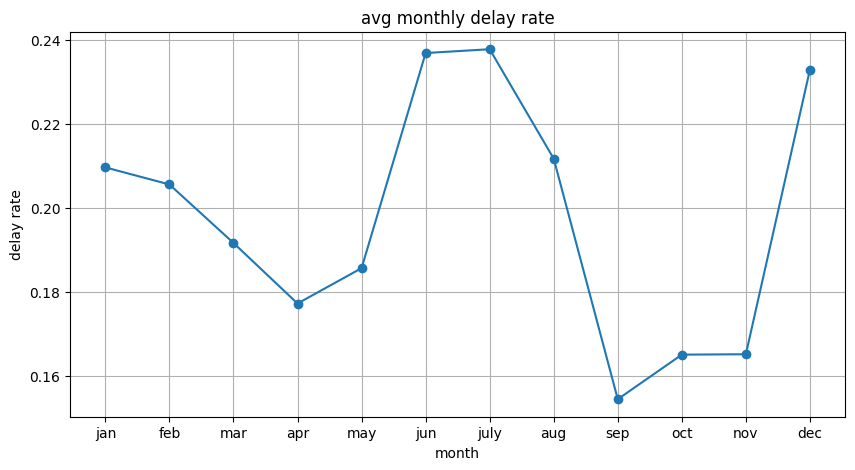

In [16]:
plt.figure(figsize=(10,5))
plt.plot(monthly_rate.index, monthly_rate.values, marker="o")
plt.title("avg monthly delay rate")
plt.xlabel("month")
plt.ylabel("delay rate")
plt.grid(True)
plt.show()

NOW I WANT TO KNOW WHICH ARE THE MOST DELAYED AIRPORTS

In [17]:
airport_delay = df.groupby("airport_name")["delay_rate"].mean().sort_values(ascending=False)

print(airport_delay.head(10))

airport_name
Youngstown/Warren, OH: Youngstown-Warren Regional    1.000000
Pinehurst/Southern Pines, NC: Moore County           0.395018
Unalaska, AK: Unalaska Airport                       0.365747
Cold Bay, AK: Cold Bay Airport                       0.342795
Topeka, KS: Topeka Regional                          0.329791
Wilmington, DE: New Castle                           0.315595
Aguadilla, PR: Rafael Hernandez                      0.306893
Macon, GA: Middle Georgia Regional                   0.306533
Salem, OR: McNary Field                              0.294750
Naples, FL: Naples Municipal                         0.290115
Name: delay_rate, dtype: float64


HERE Youngstown/Warren, OH: Youngstown-Warren Regional AIRPORT SEEMS SUSPICIOUS AS IT SHOWS 100% DELAY RATE

In [18]:
airport = df[df["airport_name"] == "Youngstown/Warren, OH: Youngstown-Warren Regional"]

In [19]:
airport.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate
164461,2018,1,G4,Allegiant Air,YNG,"Youngstown/Warren, OH: Youngstown-Warren Regional",2.0,2.0,1.39,0.0,...,0.0,0.0,0.0,119.0,97.0,0.0,22.0,0.0,0.0,1.0


HERE ITS CLEAR THAT Youngstown/Warren, OH: Youngstown-Warren Regional AIRPORT HAD ONLY 2 FLIGHTS AND BOTH WERE DELAYED AND HENCE 100% RATE

WHICH ARE THE MOST DELAYED CARRIERS??


In [20]:
delayed_carriers = df.groupby("carrier_name")["delay_rate"].mean().sort_values(ascending=False)

In [21]:
print(delayed_carriers.head(10))

carrier_name
Peninsula Airways Inc.                       0.315089
Trans States Airlines                        0.259160
Atlantic Southeast Airlines                  0.256382
Northwest Airlines Inc.                      0.248402
Commutair Aka Champlain Enterprises, Inc.    0.238647
JetBlue Airways                              0.237603
Frontier Airlines Inc.                       0.234556
Spirit Air Lines                             0.232022
Comair Inc.                                  0.230587
American Eagle Airlines Inc.                 0.228205
Name: delay_rate, dtype: float64


WHICH REASON CAUSES THE MOST DELAYS FOR THE CARRIERS??

In [22]:
delay_causes = df.groupby('carrier_name')[['carrier_ct', 'weather_ct', 'nas_ct',
'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted']].sum()

print(delay_causes.head(5))

                             carrier_ct  weather_ct     nas_ct  security_ct  \
carrier_name                                                                  
ATA Airlines d/b/a ATA          6563.67      241.39   18176.40       336.16   
Air Wisconsin Airlines Corp    26744.79     3582.42   28601.31        21.60   
AirTran Airways Corporation    91877.21     4329.18  186493.50         0.00   
Alaska Airlines Inc.          113977.74     7385.78  136194.01      3093.91   
Alaska Airlines Network        72186.05     6296.06  116992.11      2189.73   

                             late_aircraft_ct  arr_cancelled  arr_diverted  
carrier_name                                                                
ATA Airlines d/b/a ATA                9980.38         1862.0          80.0  
Air Wisconsin Airlines Corp          39019.00        16663.0        1141.0  
AirTran Airways Corporation         203606.88        23771.0        5577.0  
Alaska Airlines Inc.                132066.86        23907.0 

In [23]:
delay_per = delay_causes.div(
    delay_causes.sum(axis=1),
    axis=0
)*100

In [24]:
print(delay_per.round(2).head(5))

                             carrier_ct  weather_ct  nas_ct  security_ct  \
carrier_name                                                               
ATA Airlines d/b/a ATA            17.63        0.65   48.81         0.90   
Air Wisconsin Airlines Corp       23.10        3.09   24.70         0.02   
AirTran Airways Corporation       17.82        0.84   36.17         0.00   
Alaska Airlines Inc.              26.94        1.75   32.19         0.73   
Alaska Airlines Network           22.85        1.99   37.04         0.69   

                             late_aircraft_ct  arr_cancelled  arr_diverted  
carrier_name                                                                
ATA Airlines d/b/a ATA                  26.80           5.00          0.21  
Air Wisconsin Airlines Corp             33.70          14.39          0.99  
AirTran Airways Corporation             39.49           4.61          1.08  
Alaska Airlines Inc.                    31.21           5.65          1.53  
Alask

In [25]:
df.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            657
arr_del15              950
carrier_ct             657
weather_ct             657
nas_ct                 657
security_ct            657
late_aircraft_ct       657
arr_cancelled          657
arr_diverted           657
arr_delay              657
carrier_delay          657
weather_delay          657
nas_delay              657
security_delay         657
late_aircraft_delay    657
delay_rate             950
dtype: int64

In [26]:
df[df['arr_flights'].isnull()].head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate
3506,2024,12,G4,Allegiant Air,BTV,"Burlington, VT: Burlington International",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4221,2024,11,C5,CommuteAir LLC dba CommuteAir,DAY,"Dayton, OH: James M Cox/Dayton International",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6899,2024,10,C5,CommuteAir LLC dba CommuteAir,PVD,"Providence, RI: Rhode Island Tf Green Internat...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8371,2024,9,G7,GoJet Airlines LLC d/b/a United Express,HHH,"Hilton Head, SC: Hilton Head Airport",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8448,2024,9,MQ,Envoy Air,CAE,"Columbia, SC: Columbia Metropolitan",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df[df['arr_flights'].isnull()].shape

(657, 22)

In [28]:
df = df.dropna(subset=["arr_flights"])

In [29]:
df.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights              0
arr_del15              293
carrier_ct               0
weather_ct               0
nas_ct                   0
security_ct              0
late_aircraft_ct         0
arr_cancelled            0
arr_diverted             0
arr_delay                0
carrier_delay            0
weather_delay            0
nas_delay                0
security_delay           0
late_aircraft_delay      0
delay_rate             293
dtype: int64

In [30]:
df[df['arr_del15'].isnull()].head(13)

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate
3208,2024,12,C5,CommuteAir LLC dba CommuteAir,AUS,"Austin, TX: Austin - Bergstrom International",1.0,NaN,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
21870,2024,2,ZW,Air Wisconsin Airlines Corp,MQT,"Marquette, MI: Marquette Sawyer Regional",3.0,NaN,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
22989,2024,1,ZW,Air Wisconsin Airlines Corp,AVP,"Scranton/Wilkes-Barre, PA: Wilkes Barre Scrant...",1.0,NaN,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
23364,2024,1,YV,Mesa Airlines Inc.,BTV,"Burlington, VT: Burlington International",1.0,NaN,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
23437,2024,1,YX,Republic Airline,CID,"Cedar Rapids/Iowa City, IA: The Eastern Iowa",1.0,NaN,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
23592,2024,1,C5,CommuteAir LLC dba CommuteAir,BDL,"Hartford, CT: Bradley International",1.0,NaN,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
32809,2023,8,G7,GoJet Airlines LLC d/b/a United Express,CHS,"Charleston, SC: Charleston AFB/International",1.0,NaN,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
34717,2023,7,G7,GoJet Airlines LLC d/b/a United Express,RDU,"Raleigh/Durham, NC: Raleigh-Durham International",1.0,NaN,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
36169,2023,6,C5,CommuteAir LLC dba CommuteAir,CHS,"Charleston, SC: Charleston AFB/International",1.0,NaN,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
36572,2023,6,G7,GoJet Airlines LLC d/b/a United Express,CLT,"Charlotte, NC: Charlotte Douglas International",1.0,NaN,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [31]:
missing_delays = df[df['arr_del15'].isnull()]

In [32]:
(missing_delays["arr_cancelled"] == missing_delays["arr_flights"]).mean()

np.float64(0.8771331058020477)

In [33]:
df = df.dropna(subset="arr_del15")

In [34]:
df.shape

(397283, 22)

WHILE TRYING TO FIND IF THE DATA CONSISTS OF ANY NULL VALUES, I FOUND THAT THERE WHERE 657 NULL ROWS OF THE FLIGHT COUNTS FOR THAT AIRPORT, AIRPLANE COMBINATION. AFTER THE INSPECTION I RELAISED ALL THE DELAY RELATED COLUMNS ARE NULL TOO. AND AS 657 IS TINY PART OF THE ~398K DATASET I DROPPED THESE 657 ROWS. AFTER THIS THERE WERE STILL SOME 293 NULL ROWS REMAINING IN ARR_DELAY15 COLUMN AFTER INSPECTION IT WAS FOUND THAT THESE ROWS HAD VERY FEW FLIGHT COUNTS OF SOME 2-3 HENCE THESE WERE DROPPED TOO.

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397283 entries, 0 to 398232
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 397283 non-null  int64  
 1   month                397283 non-null  int64  
 2   carrier              397283 non-null  object 
 3   carrier_name         397283 non-null  object 
 4   airport              397283 non-null  object 
 5   airport_name         397283 non-null  object 
 6   arr_flights          397283 non-null  float64
 7   arr_del15            397283 non-null  float64
 8   carrier_ct           397283 non-null  float64
 9   weather_ct           397283 non-null  float64
 10  nas_ct               397283 non-null  float64
 11  security_ct          397283 non-null  float64
 12  late_aircraft_ct     397283 non-null  float64
 13  arr_cancelled        397283 non-null  float64
 14  arr_diverted         397283 non-null  float64
 15  arr_delay            3

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,397283.0,2014.417476,6.475406,2003.00,2009.000000,2015.000000,2020.000000,2025.00
month,397283.0,6.524981,3.463720,1.00,4.000000,7.000000,10.000000,12.00
arr_flights,397283.0,361.924646,994.267241,1.00,56.000000,113.000000,255.000000,21977.00
arr_del15,397283.0,69.593947,193.608821,0.00,8.000000,21.000000,52.000000,6377.00
carrier_ct,397283.0,20.555480,48.328799,0.00,2.800000,7.520000,18.670000,1886.58
weather_ct,397283.0,2.510081,9.574126,0.00,0.000000,0.510000,2.000000,717.94
nas_ct,397283.0,22.225908,79.500064,-0.01,1.400000,4.920000,14.000000,4091.27
security_ct,397283.0,0.172757,0.826539,0.00,0.000000,0.000000,0.000000,80.56
late_aircraft_ct,397283.0,24.129755,74.439276,0.00,1.520000,5.500000,16.160000,2588.13
arr_cancelled,397283.0,6.788818,35.096553,0.00,0.000000,1.000000,4.000000,4951.00


Airport-airline-month traffic is highly skewed. While the median observation contains only 113 arriving flights, some observations exceed 21,000 flights. This indicates a small number of extremely busy airport-airline combinations.

Also Security-related delays are extremely rare

In [37]:
df[df["nas_delay"] < 0].T

,375209,394641
year,2004,2003
month,11,8
carrier,EV,B6
carrier_name,Atlantic Southeast Airlines,JetBlue Airways
airport,BWI,SLC
airport_name,"Baltimore, MD: Baltimore/Washington Internatio...","Salt Lake City, UT: Salt Lake City International"
arr_flights,30.0,62.0
arr_del15,7.0,11.0
carrier_ct,3.51,5.22
weather_ct,3.51,0.79


In [38]:
df[df["nas_ct"] < 0]

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate
375209,2004,11,EV,Atlantic Southeast Airlines,BWI,"Baltimore, MD: Baltimore/Washington Internatio...",30.0,7.0,3.51,3.51,...,0.0,0.0,0.0,414.0,199.0,216.0,-1.0,0.0,0.0,0.233333


In [39]:
df["nas_delay"] = df["nas_delay"].clip(lower=0)
df["nas_ct"] = df["nas_ct"].clip(lower=0)

Two observations contained small negative values in NAS-related delay variables (nas_ct, nas_delay). Since negative delays are not meaningful and the values were extremely small, they clipped to zero.

<Axes: xlabel='arr_flights', ylabel='Count'>

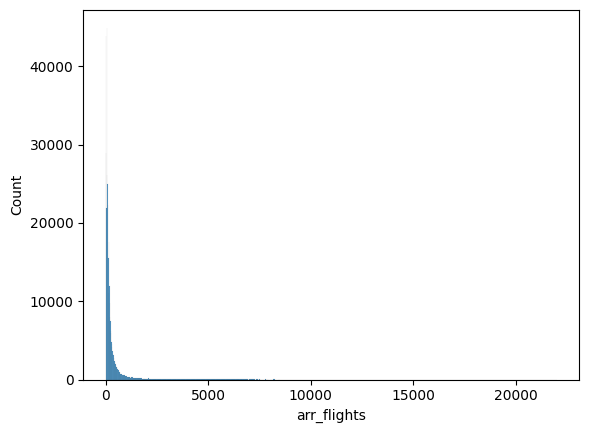

In [40]:
sns.histplot(x = df['arr_flights'])

WE CAN SEE THAT THE POINTS OF ARR_FLIGHTS ARE EXTREMLY RIGHT SKEWED HENCE I APPLIED LOG TRANSFORMED

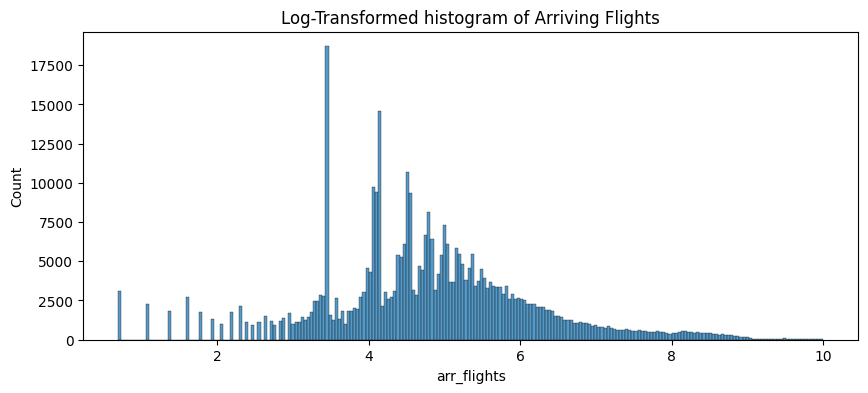

In [41]:
plt.figure(figsize=(10,4))
sns.histplot(x=np.log1p(df["arr_flights"]))
plt.title("Log-Transformed histogram of Arriving Flights")
plt.show()

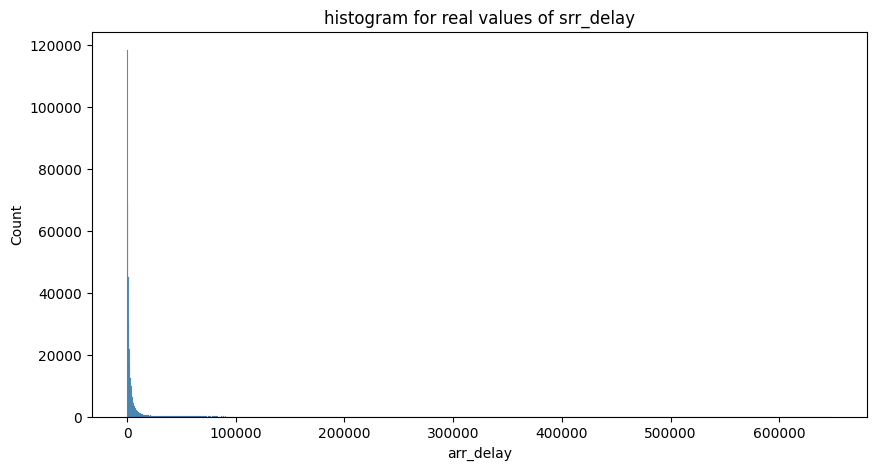

In [42]:
plt.figure(figsize=(10,5))
sns.histplot(x = df['arr_delay'])
plt.title("histogram for real values of srr_delay")
plt.show()

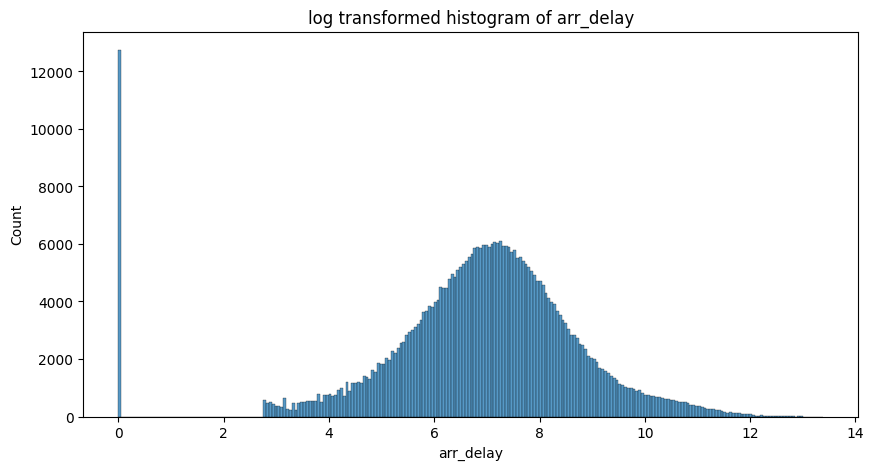

In [43]:
plt.figure(figsize=(10,5))
sns.histplot(x = np.log1p(df['arr_delay']))
plt.title("log transformed histogram of arr_delay")
plt.show()

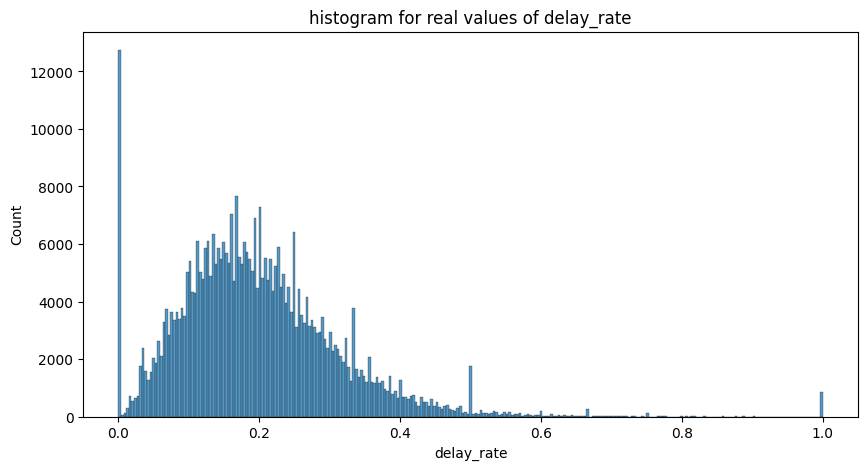

In [44]:
plt.figure(figsize=(10,5))
sns.histplot(x = df['delay_rate'])
plt.title("histogram for real values of delay_rate")
plt.show()

In [45]:
df[df['delay_rate']==0].shape

(12742, 22)

c:\Users\sarth\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


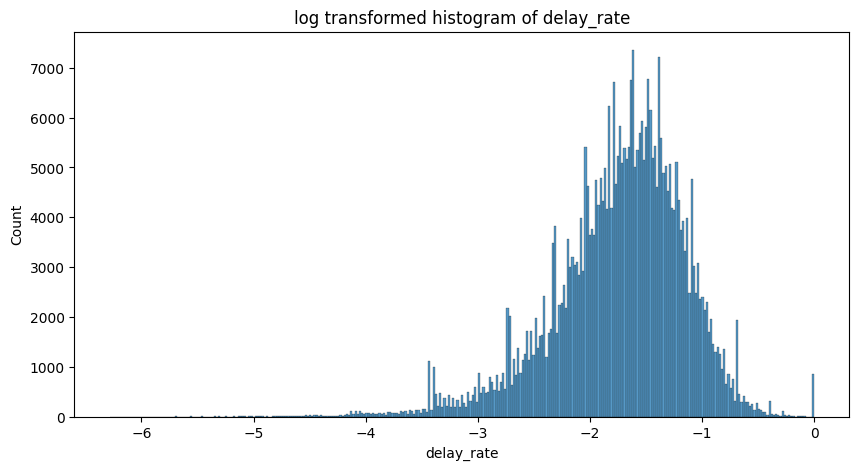

In [46]:
plt.figure(figsize=(10,5))
sns.histplot(x = np.log(df['delay_rate']))
plt.title("log transformed histogram of delay_rate")
plt.show()

In [47]:
corr_cols = [
    'arr_flights',
    'arr_del15',
    'carrier_ct',
    'weather_ct',
    'nas_ct',
    'security_ct',
    'late_aircraft_ct',
    'arr_delay',
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'late_aircraft_delay',
    'delay_rate'
]

corr = df[corr_cols].corr()

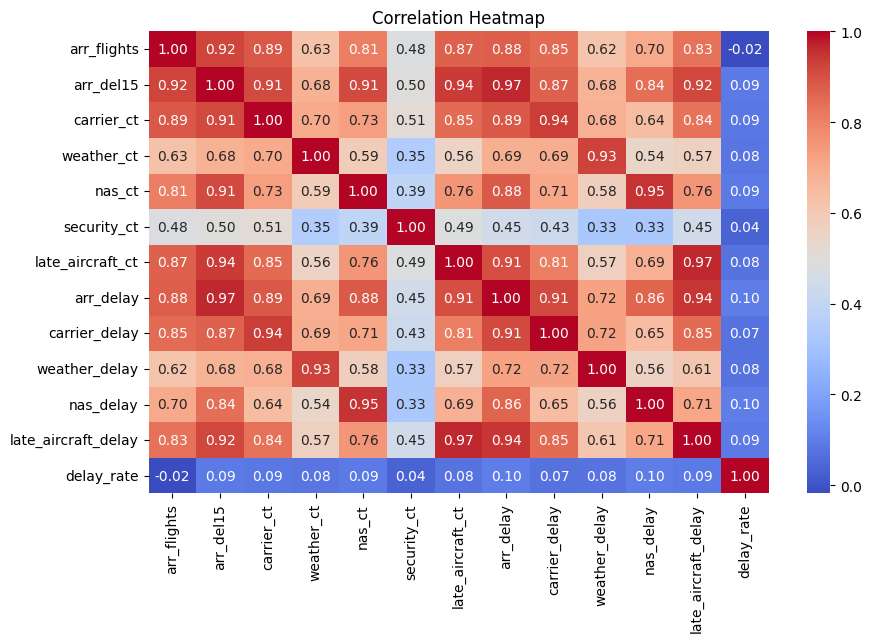

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [49]:
high_delay_cause = df.groupby('carrier_name')[[
    'carrier_ct',
    'weather_ct',
    'nas_ct',
    'security_ct',
    'late_aircraft_ct'
]].sum()

In [50]:
high_delay_cause['main_cause'] = high_delay_cause.idxmax(axis=1)

high_delay_cause[['main_cause']]

,main_cause
carrier_name,
ATA Airlines d/b/a ATA,nas_ct
Air Wisconsin Airlines Corp,late_aircraft_ct
AirTran Airways Corporation,late_aircraft_ct
Alaska Airlines Inc.,nas_ct
Alaska Airlines Network,nas_ct
Allegiant Air,late_aircraft_ct
Aloha Airlines Inc.,carrier_ct
America West Airlines Inc.,nas_ct
American Airlines Inc.,nas_ct


In [51]:
high_delay_cause['main_cause'].value_counts()

main_cause
nas_ct              21
late_aircraft_ct    21
carrier_ct           9
Name: count, dtype: int64

In [52]:
df.to_csv(
    "../processed_data/eda_cleaned.csv",
    index=False
)